## N-BEATS

In [ ]:
# ── Colab / Local setup ──────────────────────────────────────────────────
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Clone the repo
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting

    # 2. Install dependencies
    %pip install -q -r requirements.txt

    # 3. Inject Colab secrets as environment variables
    import os
    from google.colab import userdata
    os.environ["DAGSHUB_TOKEN"]    = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]    = userdata.get("WANDB_API_KEY")

    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

    # 4. Download competition data
    %pip install -q kaggle
    import os
    os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


### 1. Setup and Imports

In [4]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("NIXTLA_ID_AS_COL", "1")

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature

import wandb

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking

from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.pipeline.dlinear_pipeline import to_long_format
from src.pipeline.nbeats_pipeline import NBEATSForecastPipeline
from src.training_diagnostics import GradientNormLogger, log_gradient_diagnostics, strip_neuralforecast_callbacks

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

print("Current MLflow URI:", mlflow.get_tracking_uri())

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE   = "#7196C7"
PINK   = "#AE737D"
PURPLE = "#705588"
RED    = "#7E3838"
GREEN  = "#5E9D74"

REGIME_COLORS = {
    "underfit": PURPLE,
    "balanced": BLUE,
    "overfit":  RED,
}

STATUS_COLORS = {
    "good":     GREEN,
    "underfit": PURPLE,
    "overfit":  RED,
}

print("Setup complete.")

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Current MLflow URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [5]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "NBEATS_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY  = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

# N-BEATS uses interpretable stacks (trend + seasonality) or generic (identity).
# n_harmonics controls Fourier terms for the seasonality stack.
# n_polynomials controls the polynomial degree for the trend stack.
# Both are always passed; they are only active for the relevant stack type.
CONFIG = {
    "input_size":     52,
    "horizon":        26,
    "stack_types":    ["trend", "seasonality"],
    "n_blocks":       [3, 3],
    "mlp_units":      [[512, 512], [512, 512]],
    "n_harmonics":    4,
    "n_polynomials":  3,
    "batch_size":     128,
    "learning_rate":  1e-3,
    "max_steps":      500,
    "random_seed":    42,
}

FREQ = "W-FRI"

CONFIG

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


{'input_size': 52,
 'horizon': 26,
 'stack_types': ['trend', 'seasonality'],
 'n_blocks': [3, 3],
 'mlp_units': [[512, 512], [512, 512]],
 'n_harmonics': 4,
 'n_polynomials': 3,
 'batch_size': 128,
 'learning_rate': 0.001,
 'max_steps': 500,
 'random_seed': 42}

### 3. Load Data

In [6]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()

train_df.head()

train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [7]:
train_feat = apply_shared_features(train_df)

print(f"Columns after shared feature engineering: {train_feat.shape[1]}")
train_feat.head()

Columns after shared feature engineering: 23


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Model-Specific Feature Engineering

In [8]:
# N-BEATS (standard) is target-history-only — no exogenous variables.
# The interpretable stack types (trend/seasonality) are the model's
# inductive bias for decomposing the series, not extra input features.
# We convert to NeuralForecast long format with only unique_id, ds, y.

long_df = to_long_format(train_feat, include_target=True)

print(f"long_df shape: {long_df.shape}")
print(f"Number of time series: {long_df['unique_id'].nunique()}")
print("\nColumns used by N-BEATS:")
print(long_df.columns.tolist())

print("\nExample series:")
example_id = long_df["unique_id"].iloc[0]
display(long_df[long_df["unique_id"] == example_id].head(10))

long_df shape: (421570, 3)
Number of time series: 3331

Columns used by N-BEATS:
['unique_id', 'ds', 'y']

Example series:


,unique_id,ds,y
0,10_1,2010-02-05,40212.84
1,10_1,2010-02-12,67699.32
2,10_1,2010-02-19,49748.33
3,10_1,2010-02-26,33601.22
4,10_1,2010-03-05,36572.44
5,10_1,2010-03-12,36380.70
6,10_1,2010-03-19,38252.33
7,10_1,2010-03-26,51956.73
8,10_1,2010-04-02,131853.01
9,10_1,2010-04-09,89207.79


### 6. Feature Selection

In [9]:
exogenous_support = {
    "future_exogenous":   getattr(NBEATS, "EXOGENOUS_FUTR", False),
    "historical_exogenous": getattr(NBEATS, "EXOGENOUS_HIST", False),
    "static_exogenous":   getattr(NBEATS, "EXOGENOUS_STAT", False),
}

display(pd.Series(exogenous_support, name="NBEATS exogenous support"))

NBEATS_FEATURE_DECISION = {
    "feature_set": "target_history_only",
    "uses_exogenous_features": False,
    "used_model_columns": "unique_id, ds, y",
    "reason": (
        "Standard NeuralForecast NBEATS does not support exogenous variables. "
        "Seasonality and trend are captured through the model's basis expansion "
        "(interpretable stacks with Fourier/polynomial bases), not via extra input features."
    ),
}

NBEATS_FEATURE_DECISION

future_exogenous        False
historical_exogenous    False
static_exogenous        False
Name: NBEATS exogenous support, dtype: bool

{'feature_set': 'target_history_only',
 'uses_exogenous_features': False,
 'used_model_columns': 'unique_id, ds, y',
 'reason': "Standard NeuralForecast NBEATS does not support exogenous variables. Seasonality and trend are captured through the model's basis expansion (interpretable stacks with Fourier/polynomial bases), not via extra input features."}

### 7. Time-Series and Window Setup

In [10]:
train_part, valid_part = time_based_split(train_feat, valid_weeks=CONFIG["horizon"])

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")
print(f"\nInput size:       {CONFIG['input_size']} weeks")
print(f"Forecast horizon: {CONFIG['horizon']} weeks")

series_lengths = long_df.groupby("unique_id").size()

NBEATS_SERIES_LENGTH = int(series_lengths.max())
nbeats_ids = series_lengths[series_lengths == NBEATS_SERIES_LENGTH].index
nbeats_df  = long_df[long_df["unique_id"].isin(nbeats_ids)].copy()

print("\nSeries length summary:")
display(series_lengths.describe())

print("\nShortest series length:", series_lengths.min())
print("Longest series length:",  series_lengths.max())
print(
    "Number of series shorter than input_size:",
    (series_lengths < CONFIG["input_size"]).sum()
)
print(
    "Number of series shorter than input_size + horizon:",
    (series_lengths < (CONFIG["input_size"] + CONFIG["horizon"])).sum(),
)

print("\nN-BEATS training/evaluation frame:")
print(f"Using {nbeats_df['unique_id'].nunique()} complete-history series")
print(f"Dropping {long_df['unique_id'].nunique() - nbeats_df['unique_id'].nunique()} ragged/short series")
print(f"Rows used by N-BEATS: {nbeats_df.shape[0]:,}")


def ensure_unique_id_column(df):
    if "unique_id" not in df.columns and df.index.name == "unique_id":
        return df.reset_index()
    return df


def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return np.nan
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"


def save_neuralforecast_model(nf_model, path, overwrite=True, save_dataset=True):
    if not hasattr(nf_model, "prediction_intervals"):
        nf_model.prediction_intervals = None
    if not hasattr(nf_model, "_cs_df"):
        nf_model._cs_df = None
    nf_model.save(path=path, overwrite=overwrite, save_dataset=save_dataset)

Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

Input size:       52 weeks
Forecast horizon: 39 weeks

Series length summary:


count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64


Shortest series length: 1
Longest series length: 143
Number of series shorter than input_size: 340
Number of series shorter than input_size + horizon: 431

N-BEATS training/evaluation frame:
Using 2660 complete-history series
Dropping 671 ragged/short series
Rows used by N-BEATS: 380,380


### 8. Forward and Backward Check

In [11]:
tiny_ids = long_df["unique_id"].unique()[:5]
tiny_df  = long_df[long_df["unique_id"].isin(tiny_ids)]

sanity_model = NBEATS(
    h=CONFIG["horizon"],
    input_size=CONFIG["input_size"],
    stack_types=["identity"],
    n_blocks=[1],
    mlp_units=[[128, 128]],
    n_harmonics=2,
    n_polynomials=2,
    max_steps=2,
    batch_size=8,
    learning_rate=CONFIG["learning_rate"],
    random_seed=CONFIG["random_seed"],
    start_padding_enabled=True,
    scaler_type="robust",
    accelerator="cpu",
    devices=1,
)

sanity_nf = NeuralForecast(models=[sanity_model], freq=FREQ)

print("Testing N-BEATS target-history-only setup...")

sanity_cv = sanity_nf.cross_validation(
    df=tiny_df,
    n_windows=1,
    step_size=CONFIG["horizon"],
)

expected_rows = len(tiny_ids) * CONFIG["horizon"]

assert len(sanity_cv) == expected_rows
assert sanity_cv["NBEATS"].notna().all()

print("Forward/backward sanity check passed:", sanity_cv.shape)
display(sanity_cv.head())

Seed set to 42


/home/davit/ml/ml-final-project-walmart-recruiting/venv/lib/python3.12/site-packages/neuralforecast/common/_base_model.py:749: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(


Testing N-BEATS target-history-only setup...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 35.0 K | train
--------------------------------------------------------------
35.0 K    Trainable params
0         Non-trainable params
35.0 K    Total params
0.140     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Forward/backward sanity check passed: (195, 5)


,unique_id,ds,cutoff,NBEATS,y
0,10_1,2012-02-03,2012-01-27,31491.701172,36444.00
1,10_1,2012-02-10,2012-01-27,30222.726562,50434.11
2,10_1,2012-02-17,2012-01-27,33190.480469,74930.33
3,10_1,2012-02-24,2012-01-27,32812.902344,28751.57
4,10_1,2012-03-02,2012-01-27,33223.812500,30525.88


### 9. Baseline Run

In [ ]:
holiday_lookup = train_feat.assign(
    unique_id=train_feat["Store"].astype(str) + "_" + train_feat["Dept"].astype(str),
    ds=train_feat["Date"],
)[["unique_id", "ds", "IsHoliday"]].drop_duplicates()

holiday_lookup["IsHoliday"] = holiday_lookup["IsHoliday"].fillna(False).astype(bool)

display(holiday_lookup.head())


with mlflow.start_run(run_name="NBEATS_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="NBEATS_Baseline",
        group="NBEATS",
        job_type="baseline",
        tags=["NBEATS", "baseline", "target_history_only"],
        config={
            **CONFIG,
            "feature_set": NBEATS_FEATURE_DECISION["feature_set"],
            "uses_exogenous_features": NBEATS_FEATURE_DECISION["uses_exogenous_features"],
            "nbeats_series_length": NBEATS_SERIES_LENGTH,
            "nbeats_n_series": nbeats_df["unique_id"].nunique(),
        },
        reinit=True,
    )

    try:
        gradient_callback = GradientNormLogger(log_every_n_steps=10)

        baseline_model = NBEATS(
            h=CONFIG["horizon"],
            input_size=CONFIG["input_size"],
            stack_types=CONFIG["stack_types"],
            n_blocks=CONFIG["n_blocks"],
            mlp_units=CONFIG["mlp_units"],
            n_harmonics=CONFIG["n_harmonics"],
            n_polynomials=CONFIG["n_polynomials"],
            max_steps=CONFIG["max_steps"],
            batch_size=CONFIG["batch_size"],
            learning_rate=CONFIG["learning_rate"],
            random_seed=CONFIG["random_seed"],
            start_padding_enabled=True,
            scaler_type="robust",
            accelerator="cpu",
            devices=1,
            callbacks=[gradient_callback],
        )

        baseline_nf = NeuralForecast(models=[baseline_model], freq=FREQ)

        cv_df = baseline_nf.cross_validation(
            df=nbeats_df,
            n_windows=1,
            step_size=CONFIG["horizon"],
        )
        cv_df = ensure_unique_id_column(cv_df)
        cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)

        val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col="NBEATS", holiday_col="IsHoliday")

        train_pred_df = baseline_nf.predict_insample(step_size=CONFIG["horizon"])
        train_pred_df = ensure_unique_id_column(train_pred_df)
        train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)

        train_wmae = wmae_from_df(train_pred_df, y_true_col="y", y_pred_col="NBEATS", holiday_col="IsHoliday")

        gap_pct    = fit_gap_pct(train_wmae, val_wmae)
        fit_status = classify_fit_status(train_wmae, val_wmae)

        print(f"Baseline train WMAE: {train_wmae:,.2f}")
        print(f"Baseline val WMAE:   {val_wmae:,.2f}")
        print(f"Baseline gap:        {gap_pct:,.2f}% ({fit_status})")

        mlflow.log_params(CONFIG)
        mlflow.log_params({
            "feature_set": NBEATS_FEATURE_DECISION["feature_set"],
            "uses_exogenous_features": NBEATS_FEATURE_DECISION["uses_exogenous_features"],
            "nbeats_series_length": NBEATS_SERIES_LENGTH,
            "nbeats_n_series": nbeats_df["unique_id"].nunique(),
            "nbeats_dropped_series": long_df["unique_id"].nunique() - nbeats_df["unique_id"].nunique(),
        })
        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_metric("gap_pct", gap_pct)
        mlflow.log_param("fit_status", fit_status)
        mlflow.log_param("gradient_logging", True)

        gradient_metrics = log_gradient_diagnostics(
            gradient_callback,
            model_name="NBEATS",
            run_label="baseline",
            mlflow_module=mlflow,
            wandb_module=wandb,
        )

        wandb.log({"train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap_pct, "fit_status": fit_status})

        os.makedirs("artifacts", exist_ok=True)
        baseline_path = "artifacts/nbeats_baseline"
        save_neuralforecast_model(baseline_nf, path=baseline_path, overwrite=True)
        mlflow.log_artifacts(baseline_path, artifact_path="nf_model")

        baseline_run_id = run.info.run_id

    finally:
        wandb.finish()

### 10. Hyperparameters

In [12]:
# stack_types notes:
#   'identity'   — generic N-BEATS block (no structural bias)
#   'trend'      — polynomial basis expansion (captures slow-moving trends)
#   'seasonality'— Fourier basis expansion (captures repeating patterns)
#
# n_harmonics controls how many Fourier frequencies the seasonality stack uses.
# n_polynomials controls the polynomial degree for the trend stack.
# Both params are always passed; they only activate for the relevant stack type.

param_grid = [
    # --- Underfit: too little capacity or too few steps ---
    {"input_size": 13, "stack_types": ["identity"],              "n_blocks": [1],    "mlp_units": [[128, 128]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 10,  "learning_rate": 1e-6, "batch_size": 128, "label": "underfit_1", "regime": "underfit"},
    {"input_size": 13, "stack_types": ["identity"],              "n_blocks": [1],    "mlp_units": [[128, 128]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 30,  "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_2", "regime": "underfit"},
    {"input_size": 26, "stack_types": ["identity"],              "n_blocks": [1],    "mlp_units": [[256, 256]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 10,  "learning_rate": 1e-6, "batch_size": 128, "label": "underfit_3", "regime": "underfit"},
    {"input_size": 26, "stack_types": ["identity"],              "n_blocks": [1],    "mlp_units": [[256, 256]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 30,  "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_4", "regime": "underfit"},
    {"input_size": 13, "stack_types": ["trend", "seasonality"],  "n_blocks": [1, 1], "mlp_units": [[128, 128], [128, 128]],   "n_harmonics": 2, "n_polynomials": 2, "max_steps": 20,  "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_5", "regime": "underfit"},
    {"input_size": 26, "stack_types": ["trend", "seasonality"],  "n_blocks": [1, 1], "mlp_units": [[256, 256], [256, 256]],   "n_harmonics": 2, "n_polynomials": 2, "max_steps": 30,  "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_6", "regime": "underfit"},

    # --- Balanced: reasonable search space ---
    {"input_size": 52, "stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[512, 512]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_1",  "regime": "balanced"},
    {"input_size": 52, "stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[512, 512]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_2",  "regime": "balanced"},
    {"input_size": 52, "stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[256, 256]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 64,  "label": "balanced_3",  "regime": "balanced"},
    {"input_size": 52, "stack_types": ["identity"],              "n_blocks": [5],    "mlp_units": [[512, 512]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_4",  "regime": "balanced"},
    {"input_size": 78, "stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[512, 512]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_5",  "regime": "balanced"},
    {"input_size": 78, "stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[512, 512]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_6",  "regime": "balanced"},
    {"input_size": 52, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 2, "n_polynomials": 2, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 64,  "label": "balanced_7",  "regime": "balanced"},
    {"input_size": 52, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_8",  "regime": "balanced"},
    {"input_size": 52, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 4, "n_polynomials": 3, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_9",  "regime": "balanced"},
    {"input_size": 78, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 4, "n_polynomials": 3, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_10", "regime": "balanced"},
    {"input_size": 78, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 64,  "label": "balanced_11", "regime": "balanced"},
    {"input_size": 78, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 4, "n_polynomials": 3, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_12", "regime": "balanced"},
    {"input_size": 52, "stack_types": ["trend", "seasonality"],  "n_blocks": [5, 5], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 4, "n_polynomials": 3, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_13", "regime": "balanced"},
    {"input_size": 78, "stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[256, 256]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 5e-4, "batch_size": 64,  "label": "balanced_14", "regime": "balanced"},
    {"input_size": 104,"stack_types": ["identity"],              "n_blocks": [3],    "mlp_units": [[512, 512]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_15", "regime": "balanced"},
    {"input_size": 104,"stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[512, 512], [512, 512]],   "n_harmonics": 4, "n_polynomials": 3, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_16", "regime": "balanced"},
    {"input_size": 52, "stack_types": ["identity"],              "n_blocks": [5],    "mlp_units": [[256, 256]],              "n_harmonics": 2, "n_polynomials": 2, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 64,  "label": "balanced_17", "regime": "balanced"},
    {"input_size": 52, "stack_types": ["trend", "seasonality"],  "n_blocks": [3, 3], "mlp_units": [[256, 256], [256, 256]],   "n_harmonics": 2, "n_polynomials": 2, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_18", "regime": "balanced"},

    # --- Overfit: large capacity, too many steps, high LR ---
    {"input_size": 130,"stack_types": ["identity"],              "n_blocks": [5],    "mlp_units": [[1024, 1024]],            "n_harmonics": 2, "n_polynomials": 2, "max_steps": 2000,"learning_rate": 2e-2, "batch_size": 8,   "label": "overfit_1",  "regime": "overfit"},
    {"input_size": 130,"stack_types": ["identity"],              "n_blocks": [7],    "mlp_units": [[1024, 1024]],            "n_harmonics": 2, "n_polynomials": 2, "max_steps": 4000,"learning_rate": 5e-2, "batch_size": 8,   "label": "overfit_2",  "regime": "overfit"},
    {"input_size": 156,"stack_types": ["trend", "seasonality"],  "n_blocks": [5, 5], "mlp_units": [[1024, 1024], [1024, 1024]],"n_harmonics": 8,"n_polynomials": 5, "max_steps": 2000,"learning_rate": 2e-2, "batch_size": 8,   "label": "overfit_3",  "regime": "overfit"},
    {"input_size": 156,"stack_types": ["trend", "seasonality"],  "n_blocks": [7, 7], "mlp_units": [[1024, 1024], [1024, 1024]],"n_harmonics": 8,"n_polynomials": 5, "max_steps": 4000,"learning_rate": 5e-2, "batch_size": 8,   "label": "overfit_4",  "regime": "overfit"},
    {"input_size": 182,"stack_types": ["identity"],              "n_blocks": [5],    "mlp_units": [[1024, 1024]],            "n_harmonics": 2, "n_polynomials": 2, "max_steps": 2000,"learning_rate": 5e-2, "batch_size": 16,  "label": "overfit_5",  "regime": "overfit"},
    {"input_size": 182,"stack_types": ["trend", "seasonality"],  "n_blocks": [5, 5], "mlp_units": [[1024, 1024], [1024, 1024]],"n_harmonics": 8,"n_polynomials": 5, "max_steps": 4000,"learning_rate": 2e-2, "batch_size": 16,  "label": "overfit_6",  "regime": "overfit"},
]

print(f"Total N-BEATS configs: {len(param_grid)}")

Total N-BEATS configs: 30


### 11. N-BEATS Experiments

In [ ]:
results      = []
cv_by_label  = {}

best_val_wmae = float("inf")
best_run_id   = None
best_label    = None
best_nf_path  = None

with mlflow.start_run(run_name="NBEATS_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs", len(param_grid))
    mlflow.log_param("model", "NBEATS")
    mlflow.log_param("feature_set", NBEATS_FEATURE_DECISION["feature_set"])
    mlflow.log_param("nbeats_series_length", NBEATS_SERIES_LENGTH)
    mlflow.log_param("nbeats_n_series", nbeats_df["unique_id"].nunique())

    for original_params in param_grid:
        params = original_params.copy()
        label  = params.pop("label")
        regime = params.pop("regime")

        with mlflow.start_run(run_name=f"NBEATS_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"NBEATS_{label}",
                group="NBEATS",
                job_type="hyperparameter_sweep",
                tags=["NBEATS", regime, "target_history_only"],
                config={
                    **params,
                    "regime": regime,
                    "feature_set": NBEATS_FEATURE_DECISION["feature_set"],
                    "uses_exogenous_features": NBEATS_FEATURE_DECISION["uses_exogenous_features"],
                    "nbeats_series_length": NBEATS_SERIES_LENGTH,
                    "nbeats_n_series": nbeats_df["unique_id"].nunique(),
                },
                reinit=True,
            )

            try:
                gradient_callback = GradientNormLogger(log_every_n_steps=10)

                model = NBEATS(
                    h=CONFIG["horizon"],
                    input_size=params["input_size"],
                    stack_types=params["stack_types"],
                    n_blocks=params["n_blocks"],
                    mlp_units=params["mlp_units"],
                    n_harmonics=params["n_harmonics"],
                    n_polynomials=params["n_polynomials"],
                    max_steps=params["max_steps"],
                    learning_rate=params["learning_rate"],
                    batch_size=params["batch_size"],
                    random_seed=CONFIG["random_seed"],
                    start_padding_enabled=True,
                    scaler_type="robust",
                    accelerator="cpu",
                    devices=1,
                    callbacks=[gradient_callback],
                )

                nf = NeuralForecast(models=[model], freq=FREQ)

                cv_df = nf.cross_validation(
                    df=nbeats_df,
                    n_windows=1,
                    step_size=CONFIG["horizon"],
                )
                cv_df = ensure_unique_id_column(cv_df)
                cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)

                val_wmae = wmae_from_df(cv_df, y_true_col="y", y_pred_col="NBEATS", holiday_col="IsHoliday")

                train_pred_df = nf.predict_insample(step_size=CONFIG["horizon"])
                train_pred_df = ensure_unique_id_column(train_pred_df)
                train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)

                train_wmae = wmae_from_df(train_pred_df, y_true_col="y", y_pred_col="NBEATS", holiday_col="IsHoliday")

                gap_pct    = fit_gap_pct(train_wmae, val_wmae)
                fit_status = classify_fit_status(train_wmae, val_wmae)

                cv_by_label[label] = cv_df.copy()

                loggable_params = {
                    k: str(v) if isinstance(v, list) else v
                    for k, v in params.items()
                }

                mlflow.log_params({
                    **loggable_params,
                    "regime": regime,
                    "label": label,
                    "feature_set": NBEATS_FEATURE_DECISION["feature_set"],
                    "uses_exogenous_features": NBEATS_FEATURE_DECISION["uses_exogenous_features"],
                    "nbeats_series_length": NBEATS_SERIES_LENGTH,
                    "nbeats_n_series": nbeats_df["unique_id"].nunique(),
                })
                mlflow.log_metric("train_wmae", train_wmae)
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_metric("gap_pct", gap_pct)
                mlflow.log_param("fit_status", fit_status)
                mlflow.log_param("gradient_logging", True)

                gradient_metrics = log_gradient_diagnostics(
                    gradient_callback,
                    model_name="NBEATS",
                    run_label=label,
                    mlflow_module=mlflow,
                    wandb_module=wandb,
                )

                wandb.log({"train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap_pct, "fit_status": fit_status})

                results.append({
                    "label":   label,
                    "regime":  regime,
                    **params,
                    "feature_set": NBEATS_FEATURE_DECISION["feature_set"],
                    "train_wmae": train_wmae,
                    "val_wmae":   val_wmae,
                    "gap_pct":    gap_pct,
                    "status":     fit_status,
                    **gradient_metrics,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id   = nested_run.info.run_id
                    best_label    = label
                    best_nf_path  = f"artifacts/nbeats_{label}"

                    save_neuralforecast_model(nf, path=best_nf_path, overwrite=True)
                    mlflow.log_artifacts(best_nf_path, artifact_path="nf_model")

                    print(
                        f"New best: {best_label} | "
                        f"train WMAE = {train_wmae:,.2f} | "
                        f"val WMAE = {best_val_wmae:,.2f} | "
                        f"gap = {gap_pct:,.2f}% ({fit_status})"
                    )

            finally:
                wandb.finish()

### 11b. Recovery — Rebuild results from MLflow (run if kernel was reset)


In [13]:
# ── Recovery cell: rebuild results from MLflow if kernel was reset ──────────
import ast
import pandas as pd
import mlflow

init_tracking()
mlflow.set_experiment("NBEATS_Training")
client = mlflow.tracking.MlflowClient()

exp_id = client.get_experiment_by_name("NBEATS_Training").experiment_id

parent_runs = client.search_runs(
    experiment_ids=[exp_id],
    filter_string="tags.mlflow.runName = 'NBEATS_HyperparamSweep'",
    order_by=["start_time DESC"],
    max_results=1,
)
parent_run_id = parent_runs[0].info.run_id
print("Sweep parent run:", parent_run_id)

child_runs = client.search_runs(
    experiment_ids=[exp_id],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
    max_results=200,
)
print(f"Found {len(child_runs)} child runs")

results = []
best_val_wmae = float("inf")
best_run_id = None
best_label = None
cv_by_label = {}

for run in child_runs:
    p = run.data.params
    m = run.data.metrics
    results.append({
        "label":         p.get("label"),
        "regime":        p.get("regime"),
        "feature_set":   p.get("feature_set"),
        "input_size":    int(p["input_size"])       if "input_size"    in p else None,
        "stack_types":   ast.literal_eval(p["stack_types"]) if "stack_types" in p else None,
        "n_blocks":      ast.literal_eval(p["n_blocks"])    if "n_blocks"    in p else None,
        "mlp_units":     ast.literal_eval(p["mlp_units"])   if "mlp_units"   in p else None,
        "n_harmonics":   int(p["n_harmonics"])   if "n_harmonics"   in p else None,
        "n_polynomials": int(p["n_polynomials"]) if "n_polynomials" in p else None,
        "max_steps":     int(p["max_steps"])     if "max_steps"     in p else None,
        "learning_rate": float(p["learning_rate"]) if "learning_rate" in p else None,
        "batch_size":    int(p["batch_size"])    if "batch_size"    in p else None,
        "train_wmae": m.get("train_wmae"),
        "val_wmae":   m.get("val_wmae"),
        "gap_pct":    m.get("gap_pct"),
        "status":     p.get("fit_status"),
        "grad_total_norm_mean": m.get("grad_total_norm_mean"),
        "grad_total_norm_max":  m.get("grad_total_norm_max"),
        "grad_total_norm_last": m.get("grad_total_norm_last"),
        "run_id": run.info.run_id,
    })
    val_wmae = m.get("val_wmae", float("inf"))
    if val_wmae < best_val_wmae:
        best_val_wmae = val_wmae
        best_run_id   = run.info.run_id
        best_label    = p.get("label")

print(f"Recovered {len(results)} runs")
print(f"best_label    = {best_label}")
print(f"best_run_id   = {best_run_id}")
print(f"best_val_wmae = {best_val_wmae:,.2f}")


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Sweep parent run: 5c43254a56c041cb9ec78f0116c642df
Found 27 child runs
Recovered 27 runs
best_label    = balanced_9
best_run_id   = 4ffa4346c2674cb5a87954d391e2ea34
best_val_wmae = 1,858.23


### 12. Results

In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label", "regime", "status", "feature_set",
    "input_size", "stack_types", "n_blocks", "n_harmonics", "n_polynomials",
    "max_steps", "learning_rate", "batch_size",
    "grad_total_norm_mean", "grad_total_norm_max", "grad_total_norm_last",
    "train_wmae", "val_wmae", "gap_pct",
]

display(results_df[display_cols].head(15))

os.makedirs("reports", exist_ok=True)
results_path = "reports/nbeats_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)

,label,regime,status,feature_set,input_size,stack_types,n_blocks,n_harmonics,n_polynomials,max_steps,learning_rate,batch_size,grad_total_norm_mean,grad_total_norm_max,grad_total_norm_last,train_wmae,val_wmae,gap_pct
0,balanced_9,balanced,underfit,target_history_only,52.0,"[trend, seasonality]","[3, 3]",4.0,3.0,800.0,0.0005,128.0,0.0,0.0,0.0,10295.804339,1858.226421,-81.951615
1,balanced_6,balanced,underfit,target_history_only,78.0,[identity],[3],2.0,2.0,800.0,0.0005,128.0,0.0,0.0,0.0,10358.003343,1860.244970,-82.040506
2,balanced_8,balanced,underfit,target_history_only,52.0,"[trend, seasonality]","[3, 3]",2.0,2.0,500.0,0.0010,128.0,0.0,0.0,0.0,10258.033113,1900.606506,-81.472018
3,balanced_5,balanced,underfit,target_history_only,78.0,[identity],[3],2.0,2.0,500.0,0.0010,128.0,0.0,0.0,0.0,10360.057664,1903.508244,-81.626471
4,balanced_18,balanced,underfit,target_history_only,52.0,"[trend, seasonality]","[3, 3]",2.0,2.0,500.0,0.0010,128.0,0.0,0.0,0.0,10243.157051,1905.464587,-81.397683
5,balanced_4,balanced,underfit,target_history_only,52.0,[identity],[5],2.0,2.0,500.0,0.0010,128.0,0.0,0.0,0.0,10340.364600,1909.972991,-81.528959
6,balanced_2,balanced,underfit,target_history_only,52.0,[identity],[3],2.0,2.0,500.0,0.0010,128.0,0.0,0.0,0.0,10383.970629,1912.249011,-81.584607
7,balanced_7,balanced,underfit,target_history_only,52.0,"[trend, seasonality]","[3, 3]",2.0,2.0,300.0,0.0010,64.0,0.0,0.0,0.0,10299.409718,1912.629960,-81.429713
8,balanced_3,balanced,underfit,target_history_only,52.0,[identity],[3],2.0,2.0,500.0,0.0010,64.0,0.0,0.0,0.0,10367.206179,1917.942496,-81.499910
9,balanced_17,balanced,underfit,target_history_only,52.0,[identity],[5],2.0,2.0,800.0,0.0005,64.0,0.0,0.0,0.0,10348.934642,1927.040170,-81.379338


🏃 View run NBEATS_balanced_9 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/2/runs/4ffa4346c2674cb5a87954d391e2ea34
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/2


### 13. Plots

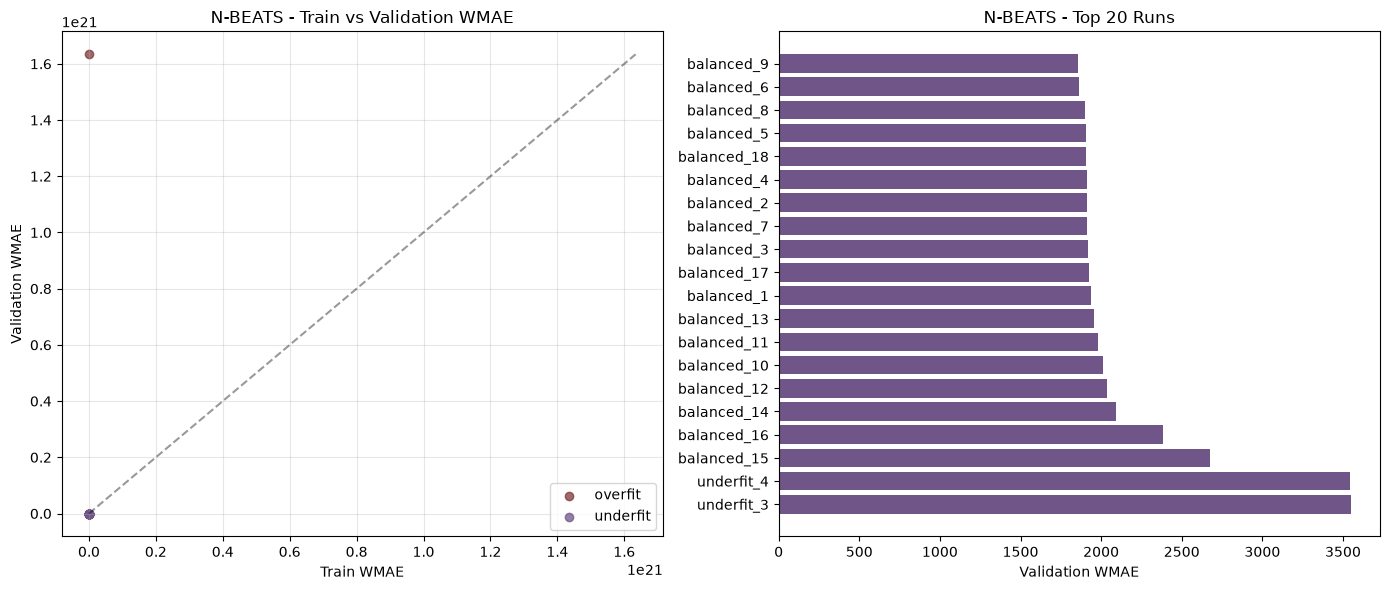

🏃 View run NBEATS_balanced_9 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/2/runs/4ffa4346c2674cb5a87954d391e2ea34
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/2


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/davit/.netrc.
wandb: Currently logged in as: dkhak22 (dkhak22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


best_gap_pct,▁
best_train_wmae,▁
best_val_wmae,▁
best_gap_pct,-81.95161
best_train_wmae,10295.80434
best_val_wmae,1858.22642


In [15]:
os.makedirs("Plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for status, status_df in results_df.groupby("status"):
    axes[0].scatter(
        status_df["train_wmae"],
        status_df["val_wmae"],
        c=STATUS_COLORS.get(status, BLUE),
        alpha=0.75,
        label=status,
    )

min_wmae = float(results_df[["train_wmae", "val_wmae"]].min().min())
max_wmae = float(results_df[["train_wmae", "val_wmae"]].max().max())
axes[0].plot([min_wmae, max_wmae], [min_wmae, max_wmae], color="black", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Train WMAE")
axes[0].set_ylabel("Validation WMAE")
axes[0].set_title("N-BEATS - Train vs Validation WMAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top20 = results_df.head(20)
axes[1].barh(
    top20["label"],
    top20["val_wmae"],
    color=top20["status"].map(lambda s: STATUS_COLORS.get(s, BLUE)),
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Validation WMAE")
axes[1].set_title("N-BEATS - Top 20 Runs")

plt.tight_layout()

plot_path = "Plots/nbeats_wmae_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="NBEATS_Analysis",
    group="NBEATS",
    job_type="analysis",
    tags=["NBEATS", "analysis", "charts", "train_validation_gap"],
    reinit=True,
)

wandb.log({
    "nbeats_wmae_comparison": wandb.Image(plot_path),
    "best_val_wmae":   best_val_wmae,
    "best_train_wmae": float(results_df.loc[results_df["label"] == best_label, "train_wmae"].iloc[0]),
    "best_gap_pct":    float(results_df.loc[results_df["label"] == best_label, "gap_pct"].iloc[0]),
})

wandb.finish()

### 14. Error Analysis

### 14b. Rebuild cv_by_label for best config (run if kernel was reset)


In [ ]:
# ── Rebuild cv_by_label for the best config only (needed for error analysis) ─
# This re-runs cross-validation for just the best config (~5 min).
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS as _NBEATS

_best = next(r for r in results if r["label"] == best_label)

_model = _NBEATS(
    h=CONFIG["horizon"],
    input_size=_best["input_size"],
    stack_types=_best["stack_types"],
    n_blocks=_best["n_blocks"],
    mlp_units=_best["mlp_units"],
    n_harmonics=_best["n_harmonics"],
    n_polynomials=_best["n_polynomials"],
    max_steps=_best["max_steps"],
    learning_rate=_best["learning_rate"],
    batch_size=_best["batch_size"],
    random_seed=CONFIG["random_seed"],
    start_padding_enabled=True,
    scaler_type="robust",
    accelerator=ACCELERATOR,
    devices=1,
)
_nf = NeuralForecast(models=[_model], freq=FREQ)
_cv = _nf.cross_validation(df=nbeats_df, n_windows=1, step_size=CONFIG["horizon"])
_cv = ensure_unique_id_column(_cv)
_cv = _cv.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
_cv["IsHoliday"] = _cv["IsHoliday"].fillna(False).astype(bool)

cv_by_label[best_label] = _cv
print(f"cv_by_label rebuilt for '{best_label}' — {len(_cv)} rows")


In [ ]:
best_cv_df = cv_by_label[best_label].copy()

best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df["NBEATS"]).abs()
best_cv_df[["Store", "Dept"]] = best_cv_df["unique_id"].str.split("_", n=1, expand=True)

display(best_cv_df.head())

worst_store_dept = (
    best_cv_df
    .groupby(["Store", "Dept"])["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(worst_store_dept)

holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()

display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae",    float(holiday_error.get(True, np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))

### 15. Error Plots

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

worst_store_dept.sort_values().plot(kind="barh", ax=ax, color=RED)

ax.set_xlabel("Mean Absolute Error")
ax.set_title("N-BEATS — Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)

plt.tight_layout()

error_plot_path = "Plots/nbeats_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="NBEATS_Error_Analysis",
    group="NBEATS",
    job_type="analysis",
    tags=["NBEATS", "error_analysis"],
    reinit=True,
)

wandb.log({
    "nbeats_worst_store_dept": wandb.Image(error_plot_path),
    "holiday_week_mae":    float(holiday_error.get(True, np.nan)),
    "nonholiday_week_mae": float(holiday_error.get(False, np.nan)),
})

wandb.finish()

### 16. Best Model

In [22]:
print("Best label:",            best_label)
print("Best run id:",           best_run_id)
print("Best validation WMAE:",  best_val_wmae)

assert best_label  is not None
assert best_run_id is not None

best_row = results_df[results_df["label"] == best_label].iloc[0]

best_params = {
    "input_size":    int(best_row["input_size"]),
    "stack_types":   best_row["stack_types"],
    "n_blocks":      best_row["n_blocks"],
    "mlp_units":     best_row["mlp_units"],
    "n_harmonics":   int(best_row["n_harmonics"]),
    "n_polynomials": int(best_row["n_polynomials"]),
    "max_steps":     int(best_row["max_steps"]),
    "learning_rate": float(best_row["learning_rate"]),
    "batch_size":    int(best_row["batch_size"]),
}

print("Best params:")
display(best_params)

fallback_by_id = (
    long_df.sort_values("ds")
    .groupby("unique_id")["y"]
    .last()
    .astype(float)
    .to_dict()
)

global_fallback = float(long_df["y"].median())

print(f"Fallback values available for {len(fallback_by_id)} series")
print(f"Global fallback Weekly_Sales: {global_fallback:,.2f}")


final_gradient_callback = GradientNormLogger(log_every_n_steps=10)

final_model = NBEATS(
    h=CONFIG["horizon"],
    input_size=best_params["input_size"],
    stack_types=best_params["stack_types"],
    n_blocks=best_params["n_blocks"],
    mlp_units=best_params["mlp_units"],
    n_harmonics=best_params["n_harmonics"],
    n_polynomials=best_params["n_polynomials"],
    max_steps=best_params["max_steps"],
    learning_rate=best_params["learning_rate"],
    batch_size=best_params["batch_size"],
    random_seed=CONFIG["random_seed"],
    start_padding_enabled=True,
    scaler_type="robust",
    accelerator="cpu",
    devices=1,
    callbacks=[final_gradient_callback],
)

final_nf = NeuralForecast(models=[final_model], freq=FREQ)
final_nf.fit(df=nbeats_df)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_param("registered_model_name", "NBEATS_WalmartForecast")
    mlflow.log_metric("best_train_wmae", float(best_row["train_wmae"]))
    mlflow.log_metric("best_val_wmae",   best_val_wmae)
    mlflow.log_metric("best_gap_pct",    float(best_row["gap_pct"]))
    mlflow.log_param("best_fit_status",  best_row["status"])
    mlflow.log_param("fallback_method",  "last_observed_sales_by_store_dept")
    mlflow.log_metric("global_fallback_weekly_sales", global_fallback)
    mlflow.log_params({f"final_{k}": str(v) if isinstance(v, list) else v for k, v in best_params.items()})
    mlflow.log_param("final_gradient_logging", True)

    log_gradient_diagnostics(
        final_gradient_callback,
        model_name="NBEATS",
        run_label=f"final_{best_label}",
        mlflow_module=mlflow,
        wandb_module=None,
    )


for model in final_nf.models:
    strip_neuralforecast_callbacks(model)

os.makedirs("artifacts", exist_ok=True)
best_nf_path = f"artifacts/nbeats_final_{best_label}"
save_neuralforecast_model(final_nf, path=best_nf_path, overwrite=True)
print("Final NeuralForecast model saved to:", best_nf_path)


pipeline_model = NBEATSForecastPipeline(
    model_col="NBEATS",
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)


class _SignatureContext:
    artifacts = {"nf_model_dir": best_nf_path}


_temp = NBEATSForecastPipeline(
    model_col="NBEATS",
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)
_temp.load_context(_SignatureContext())
sample_output = _temp.predict(_SignatureContext(), test_df)

signature = infer_signature(test_df, sample_output)

display(sample_output.head())

with mlflow.start_run(run_id=best_run_id):
    logged_model_info = mlflow.pyfunc.log_model(
        artifact_path="pipeline",
        python_model=pipeline_model,
        artifacts={"nf_model_dir": best_nf_path},
        code_paths=[str(repo_root / "src")],
        signature=signature,
        input_example=test_df.head(20),
        registered_model_name="NBEATS_WalmartForecast",
    )

model_uri = logged_model_info.model_uri
print("Logged model URI:", model_uri)

Best label: balanced_9
Best run id: 4ffa4346c2674cb5a87954d391e2ea34
Best validation WMAE: 1858.2264214612217
Best params:


{'input_size': 52,
 'stack_types': ['trend', 'seasonality'],
 'n_blocks': [3, 3],
 'mlp_units': [[512, 512], [512, 512]],
 'n_harmonics': 4,
 'n_polynomials': 3,
 'max_steps': 800,
 'learning_rate': 0.0005,
 'batch_size': 128}

Seed set to 42


Fallback values available for 3331 series
Global fallback Weekly_Sales: 7,612.03


GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.8 M  | train
--------------------------------------------------------------
3.8 M     Trainable params
41.8 K    Non-trainable params
3.8 M     Total params
15.310    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode


...

2026/07/12 22:31:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/12 22:31:42 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/12 22:31:42 INFO mlflow.pyfunc: Validating input example against model signature


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/davit/ml/ml-final-project-walmart-recruiting/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Successfully registered model 'NBEATS_WalmartForecast'.
2026/07/12 22:34:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: NBEATS_WalmartForecast, version 1
Created version '1' of model 'NBEATS_WalmartForecast'.


🏃 View run NBEATS_balanced_9 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/2/runs/4ffa4346c2674cb5a87954d391e2ea34
🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/2
Logged model URI: models:/m-9ef0c4a5d4de47039974881fe49bb5c7


### 17. Test Loading

In [23]:
loaded_model = mlflow.pyfunc.load_model(model_uri)

loaded_preds = loaded_model.predict(test_df)

print(type(loaded_preds))
print(loaded_preds.shape)

display(loaded_preds.head())

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/davit/ml/ml-final-project-walmart-recruiting/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

<class 'pandas.core.frame.DataFrame'>
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,30047.750000
1,1_1_2012-11-09,19539.214844
2,1_1_2012-11-16,19354.158203
3,1_1_2012-11-23,21954.240234
4,1_1_2012-11-30,22485.857422
